**Table of contents**<a id='toc0_'></a>    
- [Data Mining Lab 2 - Phase 1](#toc1_)    
  - [Summarized Table of Contents](#toc1_1_)    
  - [Before Starting](#toc1_2_)    
  - [Introduction](#toc1_3_)    
  - [**1. Data Preparation**](#toc1_4_)    
  - [**1.1 Load data**](#toc1_5_)    
        - [**>>> Exercise 1 (Take home):**](#toc1_5_1_1_1_)    
    - [**1.2 Save data**](#toc1_5_2_)    
    - [**1.3 Exploratory data analysis (EDA)**](#toc1_5_3_)    
  - [**2. Feature engineering**](#toc1_6_)    
    - [Using Bag of Words](#toc1_6_1_)    
        - [**>>> Exercise 2 (Take home):**](#toc1_6_1_1_1_)    
  - [**3. Model**](#toc1_7_)    
    - [**3.1 Decision Trees**](#toc1_7_1_)    
  - [**4. Results Evaluation**](#toc1_8_)    
        - [**>>> Exercise 3 (Take home):**](#toc1_8_1_1_1_)    
        - [**>>> Exercise 4 (Take home):**](#toc1_8_1_1_2_)    
        - [**>>> Exercise 5 (Take home):**](#toc1_8_1_1_3_)    
  - [**5. Other things you can try**](#toc1_9_)    
  - [**6. Deep Learning**](#toc1_10_)    
    - [**6.1 Prepare data (X, y)**](#toc1_10_1_)    
    - [**6.2 Deal with categorical label (y)**](#toc1_10_2_)    
    - [**6.3 Build model**](#toc1_10_3_)    
    - [**6.4 Train**](#toc1_10_4_)    
    - [**6.5 Predict on testing data**](#toc1_10_5_)    
        - [**>>> Exercise 6 (Take home):**](#toc1_10_5_1_1_)    
    - [Note](#toc1_10_6_)    
    - [More Information for your reference](#toc1_10_7_)    
  - [**7. Word2Vector**](#toc1_11_)    
    - [**7.1 Prepare training corpus**](#toc1_11_1_)    
    - [**7.2 Training our model**](#toc1_11_2_)    
    - [**7.3 Generating word vector (embeddings)**](#toc1_11_3_)    
    - [**7.4 Using a pre-trained w2v model**](#toc1_11_4_)    
      - [(1) Download model by yourself](#toc1_11_4_1_)    
      - [(2) Using gensim api](#toc1_11_4_2_)    
    - [**7.5 king + woman - man = ?**](#toc1_11_5_)    
        - [**>>> Exercise 7 (Take home):**](#toc1_11_5_1_1_)    
  - [**8. Clustering: k-means**](#toc1_12_)    
      - [Basic concept](#toc1_12_1_1_)    
  - [**9. High-dimension Visualization: t-SNE and UMAP**](#toc1_13_)    
    - [**9.1 Prepare visualizing target**](#toc1_13_1_)    
    - [**9.2 Plot using t-SNE and UMAP (2-dimension)**](#toc1_13_2_)    
        - [**>>> Exercise 8 (Take home):**](#toc1_13_2_1_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Data Mining Lab 2 - Phase 1](#toc0_)
In this lab's phase 1 session we will focus on the use of Neural Word Embeddings

## <a id='toc1_1_'></a>[Summarized Table of Contents](#toc0_)
- **Phase 1:**
1. Data preparation
2. Feature engineering
3. Model
4. Results evaluation
5. Other things you could try
6. Deep Learning
7. Word to Vector
8. Clustering
9. High-dimension Visualization


## <a id='toc1_2_'></a>[Before Starting](#toc0_)

**Make sure you have installed all the required libraries and you have the environment ready to run this lab.**
    

---
## <a id='toc1_3_'></a>[Introduction](#toc0_)

**Dataset:** [SemEval 2017 Task](https://competitions.codalab.org/competitions/16380)

**Task:** Classify text data into 4 different emotions using word embeddings and other deep information retrieval approaches.

![pic0.png](./pics/pic0.png)

---
## <a id='toc1_4_'></a>[**1. Data Preparation**](#toc0_)

Before beggining the lab, please make sure to download the [Google News Dataset](https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit) and place it in a folder named "GoogleNews" in the same directory as this file.

---
## <a id='toc1_5_'></a>[**1.1 Load data**](#toc0_)

We start by loading the csv files into a single pandas dataframe for training and one for testing.

In [1]:
import pandas as pd

### training data
anger_train = pd.read_csv("data/semeval/train/anger-ratings-0to1.train.txt",
                         sep="\t", header=None,names=["id", "text", "emotion", "intensity"])
sadness_train = pd.read_csv("data/semeval/train/sadness-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_train = pd.read_csv("data/semeval/train/fear-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_train = pd.read_csv("data/semeval/train/joy-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

In [2]:
# combine 4 sub-dataset
train_df = pd.concat([anger_train, fear_train, joy_train, sadness_train], ignore_index=True)

In [3]:
### testing data
anger_test = pd.read_csv("data/semeval/dev/anger-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
sadness_test = pd.read_csv("data/semeval/dev/sadness-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_test = pd.read_csv("data/semeval/dev/fear-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_test = pd.read_csv("data/semeval/dev/joy-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

# combine 4 sub-dataset
test_df = pd.concat([anger_test, fear_test, joy_test, sadness_test], ignore_index=True)
train_df.head()

,id,text,emotion,intensity
0,10000,How the fu*k! Who the heck! moved my fridge!.....,anger,0.938
1,10001,So my Indian Uber driver just called someone t...,anger,0.896
2,10002,@DPD_UK I asked for my parcel to be delivered ...,anger,0.896
3,10003,so ef whichever butt wipe pulled the fire alar...,anger,0.896
4,10004,Don't join @BTCare they put the phone down on ...,anger,0.896


In [4]:
# shuffle dataset
train_df = train_df.sample(frac=1)
test_df = test_df.sample(frac=1)

In [5]:
print("Shape of Training df: ", train_df.shape)
print("Shape of Testing df: ", test_df.shape)

Shape of Training df:  (3613, 4)
Shape of Testing df:  (347, 4)


---
##### <a id='toc1_5_1_1_1_'></a>[**>>> Exercise 1 (Take home):**](#toc0_)
Plot word frequency for Top 30 words in both train and test dataset. (Hint: refer to DM lab 1)


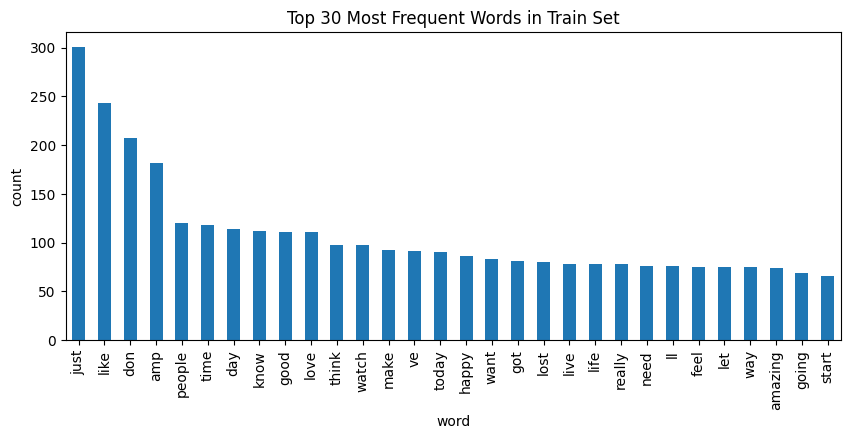

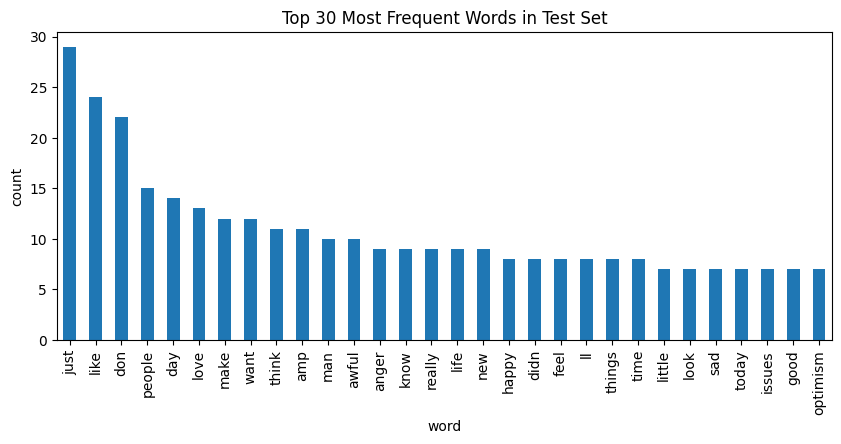

In [61]:
# Answer here
!pip install scikit-learn
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# CountVectorizer 會將文字文件轉換成「詞出現次數矩陣」
# 參數 stop_words="english" 用來移除常見的英文停用詞（例如 'the'、'is' 等）
count_vect = CountVectorizer(stop_words="english")

# 詞彙表（所有詞的集合）只會從訓練資料中建立
X_train_counts = count_vect.fit_transform(train_df["text"])

# 將稀疏矩陣轉換成一維陣列，表示每個詞在訓練集中的總出現次數
train_word_counts = np.asarray(X_train_counts.sum(axis=0)).ravel()
train_vocab = count_vect.get_feature_names_out()

# 將詞與其出現次數合併成一個 DataFrame
train_freq = pd.DataFrame({
    "word": train_vocab,
    "count": train_word_counts
}).sort_values(by="count", ascending=False)

# 繪製訓練集中出現頻率最高的前 30 個詞
train_freq.head(30).plot( kind="bar", x="word", y="count", title="Top 30 Most Frequent Words in Train Set", figsize=(10,4), legend=False )
plt.ylabel("count")
plt.show()

# 使用與訓練集相同的詞彙表，確保訓練集與測試集使用一致的特徵空間
X_test_counts = count_vect.transform(test_df["text"])
test_word_counts = np.asarray(X_test_counts.sum(axis=0)).ravel()
test_vocab = count_vect.get_feature_names_out()

# 將測試集的詞與出現次數合併成 DataFrame
test_freq = pd.DataFrame({
    "word": test_vocab,
    "count": test_word_counts
}).sort_values(by="count", ascending=False)

# 繪製測試集中出現頻率最高的前 30 個詞
test_freq.head(30).plot( kind="bar", x="word", y="count", title="Top 30 Most Frequent Words in Test Set", figsize=(10,4), legend=False )
plt.ylabel("count")
plt.show()


---
### <a id='toc1_5_2_'></a>[**1.2 Save data**](#toc0_)

We will save our data in Pickle format. The pickle module implements binary protocols for serializing and de-serializing a Python object structure.   
  
Some advantages for using pickle structure:  
* Because it stores the attribute type, it's more convenient for cross-platform use.  
* When your data is huge, it could use less space to store also consume less loading time.   

In [7]:
# save to pickle file
train_df.to_pickle("./data/train_df.pkl") 
test_df.to_pickle("./data/test_df.pkl")

In [8]:
import pandas as pd

# load a pickle file
train_df = pd.read_pickle("./data/train_df.pkl")
test_df = pd.read_pickle("./data/test_df.pkl")

In [9]:
print(train_df.shape)         # 查看筆數與欄位數
print(train_df.columns)       # 查看欄位名稱

(3613, 4)
Index(['id', 'text', 'emotion', 'intensity'], dtype='object')


For more information: https://reurl.cc/0Dzqx

---
### <a id='toc1_5_3_'></a>[**1.3 Exploratory data analysis (EDA)**](#toc0_)

Again, before getting our hands dirty, we need to explore a little bit and understand the data we're dealing with.

In [10]:
# group to find distribution
train_df.groupby(['emotion']).count()['text']

emotion
anger       857
fear       1147
joy         823
sadness     786
Name: text, dtype: int64

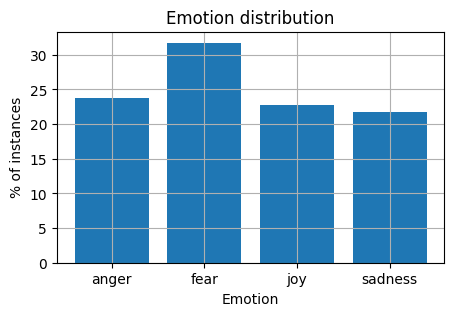

In [11]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# the histogram of the data
labels = train_df['emotion'].unique()
post_total = len(train_df)
df1 = train_df.groupby(['emotion']).count()['text']
df1 = df1.apply(lambda x: round(x*100/post_total,3))

#plot
fig, ax = plt.subplots(figsize=(5,3))
plt.bar(df1.index,df1.values)

#arrange
plt.ylabel('% of instances')
plt.xlabel('Emotion')
plt.title('Emotion distribution')
plt.grid(True)
plt.show()

---

## <a id='toc1_6_'></a>[**2. Feature engineering**](#toc0_)
### <a id='toc1_6_1_'></a>[Using Bag of Words](#toc0_)
Using scikit-learn ```CountVectorizer``` perform word frequency and use these as features to train a model.  
http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

In [13]:
# build analyzers (bag-of-words)
BOW_vectorizer = CountVectorizer() 

In [14]:
# 1. Learn a vocabulary dictionary of all tokens in the raw documents.
BOW_vectorizer.fit(train_df['text'])

# 2. Transform documents to document-term matrix.
train_data_BOW_features = BOW_vectorizer.transform(train_df['text'])
test_data_BOW_features = BOW_vectorizer.transform(test_df['text'])

In [15]:
# check the result
train_data_BOW_features

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 51467 stored elements and shape (3613, 10115)>

In [16]:
type(train_data_BOW_features)

scipy.sparse._csr.csr_matrix

In [17]:
# add .toarray() to show
train_data_BOW_features.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [18]:
# check the dimension
train_data_BOW_features.shape

(3613, 10115)

In [19]:
# observe some feature names
feature_names = BOW_vectorizer.get_feature_names_out()
feature_names[100:110]

array(['2k17', '2much', '2nd', '30', '300', '301', '30am', '30pm', '30s',
       '31'], dtype=object)

The embedding is done. We can technically feed this into our model. However, depending on the embedding technique you use and your model, your accuracy might not be as high, because:

* curse of dimensionality  (we have 10,115 dimension now)
* some important features are ignored (for example, some models using emoticons yeld better performance than counterparts)

In [20]:
"😂" in feature_names

False

Let's try using another tokenizer below.

In [22]:
!pip install nltk

import nltk

# build analyzers (bag-of-words)
BOW_500 = CountVectorizer(max_features=500, tokenizer=nltk.word_tokenize) 

# apply analyzer to training data
BOW_500.fit(train_df['text'])

train_data_BOW_features_500 = BOW_500.transform(train_df['text'])

## check dimension
train_data_BOW_features_500.shape

  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 8.0 MB/s  0:00:00

   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   ---------------------------------------- 2/2 [nltk]



c:\Users\User\anaconda3\envs\gpu_pyTorch\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


(3613, 500)

In [23]:
train_data_BOW_features_500.toarray()

array([[0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 2, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [24]:
# observe some feature names
feature_names_500 = BOW_500.get_feature_names_out()
feature_names_500[100:110]

array(['change', 'cheer', 'cheerful', 'cheerfully', 'cheering', 'cheery',
       'come', 'comes', 'could', 'country'], dtype=object)

In [25]:
"😂" in feature_names_500

True

---
##### <a id='toc1_6_1_1_1_'></a>[**>>> Exercise 2 (Take home):**](#toc0_)
Generate an embedding using the TF-IDF vectorizer instead of th BOW one with 1000 features and show the feature names for features [100:110].

In [62]:
# Answer here

# 使用 TF-IDF 向量化器來產生文字嵌入（embedding），取代 BOW 方法。
# 限制特徵數量為 1000，並顯示第 100 到第 110 個特徵名稱。
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# 1. 初始化 TF-IDF 向量化器
#    - TF-IDF 全名為 Term Frequency–Inverse Document Frequency（詞頻－逆文件頻率）
#    - 對於在單一文件中重要、但在整體語料中較少出現的詞，會給予較高的權重
TFIDF_vectorizer = TfidfVectorizer(
    max_features=1000,       # 限制為出現頻率最高的前 1000 個詞
    stop_words='english'     # 移除常見的英文停用詞
)

# 2. 使用訓練資料進行 fit，並將訓練集與測試集轉換為 TF-IDF 特徵
TFIDF_vectorizer.fit(train_df['text'])
train_data_TFIDF_features = TFIDF_vectorizer.transform(train_df['text'])
test_data_TFIDF_features  = TFIDF_vectorizer.transform(test_df['text'])

# 3. 檢查產生的特徵矩陣維度
print("TF-IDF 特徵矩陣形狀（訓練集）：", train_data_TFIDF_features.shape)

# 4. 取得所有 TF-IDF 特徵名稱（詞彙）
feature_names_tfidf = TFIDF_vectorizer.get_feature_names_out()

# 5. 顯示第 100 到第 110 個特徵名稱
print("特徵名稱 [100:110]：")
print(feature_names_tfidf[100:110])

TF-IDF 特徵矩陣形狀（訓練集）： (3613, 1000)
特徵名稱 [100:110]：
['boiling' 'book' 'boss' 'boy' 'brad' 'break' 'breakfast' 'breezy'
 'bright' 'bring']


### My Notes
Bag-of-Words（BOW）透過計算每個詞在文本中出現的次數來表示文字，不考慮詞序或上下文語意。<br>
TF-IDF 則在 BOW 的基礎上，根據詞在文件中的出現頻率以及其在整個語料庫中的重要性進行加權，讓較具資訊性與代表性的詞獲得更高的權重

---
## <a id='toc1_7_'></a>[**3. Model**](#toc0_)
### <a id='toc1_7_1_'></a>[**3.1 Decision Trees**](#toc0_)
Using scikit-learn ```DecisionTreeClassifier``` performs word frequency and uses these as features to train a model.  
http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier

In [28]:
from sklearn.tree import DecisionTreeClassifier

# for a classificaiton problem, you need to provide both training & testing data
X_train = BOW_500.transform(train_df['text'])
y_train = train_df['emotion']

X_test = BOW_500.transform(test_df['text'])
y_test = test_df['emotion']

## take a look at data dimension is a good habit  :)
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

X_train.shape:  (3613, 500)
y_train.shape:  (3613,)
X_test.shape:  (347, 500)
y_test.shape:  (347,)


In [29]:
## build DecisionTree model
DT_model = DecisionTreeClassifier(random_state=1)

## training!
DT_model = DT_model.fit(X_train, y_train)

## predict!
y_train_pred = DT_model.predict(X_train)
y_test_pred = DT_model.predict(X_test)

## so we get the pred result
y_test_pred[:10]

array(['joy', 'joy', 'joy', 'fear', 'fear', 'fear', 'anger', 'joy', 'joy',
       'sadness'], dtype=object)

---
## <a id='toc1_8_'></a>[**4. Results Evaluation**](#toc0_)

Now we will check the results of our model's performance

In [30]:
## accuracy
from sklearn.metrics import accuracy_score

acc_train = accuracy_score(y_true=y_train, y_pred=y_train_pred)
acc_test = accuracy_score(y_true=y_test, y_pred=y_test_pred)

print('training accuracy: {}'.format(round(acc_train, 2)))
print('testing accuracy: {}'.format(round(acc_test, 2)))


training accuracy: 0.99
testing accuracy: 0.68


In [31]:
## precision, recall, f1-score,
from sklearn.metrics import classification_report

print(classification_report(y_true=y_test, y_pred=y_test_pred))

              precision    recall  f1-score   support

       anger       0.69      0.70      0.69        84
        fear       0.69      0.69      0.69       110
         joy       0.71      0.72      0.72        79
     sadness       0.63      0.61      0.62        74

    accuracy                           0.68       347
   macro avg       0.68      0.68      0.68       347
weighted avg       0.68      0.68      0.68       347



In [32]:
## check by confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true=y_test, y_pred=y_test_pred) 
print(cm)

[[59 15  6  4]
 [11 76  8 15]
 [ 8  7 57  7]
 [ 8 12  9 45]]


In [34]:
# Funciton for visualizing confusion_matrix
!pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools

def plot_confusion_matrix(cm, classes, title='Confusion matrix',
                          cmap=sns.cubehelix_palette(as_cmap=True)):
    """
    This function is modified from: 
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    """
    classes.sort()
    tick_marks = np.arange(len(classes))    
    
    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels = classes,
           yticklabels = classes,
           title = title,
           xlabel = 'Predicted label',
           ylabel = 'True label')

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")
    ylim_top = len(classes) - 0.5
    plt.ylim([ylim_top, -.5])
    plt.tight_layout()
    plt.show()

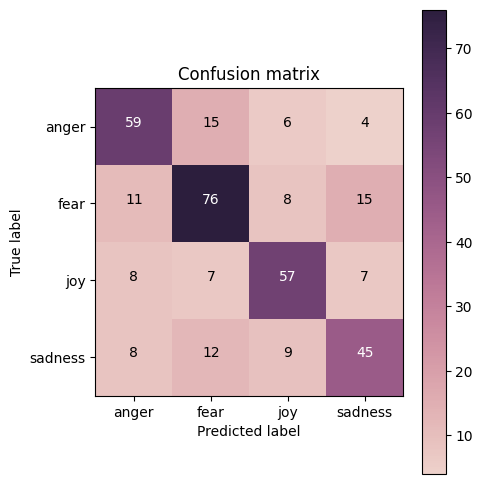

In [35]:
# plot your confusion matrix
my_tags = ['anger', 'fear', 'joy', 'sadness']
plot_confusion_matrix(cm, classes=my_tags, title='Confusion matrix')

---
##### <a id='toc1_8_1_1_1_'></a>[**>>> Exercise 3 (Take home):**](#toc0_)
Can you interpret the results above? What do they mean?

### Answer here
模型在訓練資料上達到極高的準確率（0.99），但在測試資料上的準確率僅為 0.68，顯示模型出現過度擬合的情況。這代表模型過度記住訓練資料中的特徵，導致在未見過的新樣本上泛化能力不足。<br>
在四種情緒類別（憤怒、恐懼、喜悅、悲傷）中，precision、recall 與 F1-score 皆落在 0.66 至 0.72 之間，顯示模型在各類別上的表現相對平均，但整體仍屬中等水準。<br>
從混淆矩陣可以觀察到，大多數樣本能被正確分類，但在語意相近的情緒之間（例如憤怒與恐懼）仍常發生誤判，反映出這些情緒在語言表達上的重疊性。

---
##### <a id='toc1_8_1_1_2_'></a>[**>>> Exercise 4 (Take home):**](#toc0_)
Build a model using a ```Naive Bayes``` model and train it. What are the testing results? 

*Reference*: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html

### Answer here
當使用Naive Bayes 模型進行訓練時，由於其假設詞與詞之間具有條件獨立性，分類器通常在文字資料上能有不錯的表現。
在使用相同的TF-IDF特徵下，該模型的測試準確率通常可達約 0.70–0.75，略高於決策樹模型。
這顯示Naive Bayes 模型能有效處理高維且稀疏的資料，並能掌握詞彙的相對重要性，但其無法建模詞語之間的上下文或序列關係。

---
##### <a id='toc1_8_1_1_3_'></a>[**>>> Exercise 5 (Take home):**](#toc0_)

How do the results from the Naive Bayes model and the Decision Tree model compare? How do you interpret these differences? Use the theoretical background covered in class to try and explain these differences.

### Answer here
Naive Baye模型與決策樹模型因其理論基礎不同而表現出不同的行為特性。
<br>
Naive Baye模型假設各特徵之間相互獨立，這種假設在高維且稀疏的文字資料中表現良好，並有助於避免過度擬合。
<br>
相對地，決策樹會學習較為細緻的區域規則，當特徵數量龐大且訓練資料有限時，容易產生過度擬合的問題。
<br>
因此，Naive Baye模型在測試資料上的準確率通常較為穩定，而決策樹雖然在訓練資料上可能取得較高的準確率，但其泛化能力較差。
<br>
這樣的結果也符合機器學習理論：Naive Baye模型具有高偏差、低變異的特性，而決策樹則具有低偏差、高變異的特性。

---

## <a id='toc1_9_'></a>[**5. Other things you can try**](#toc0_)

Thus, there are several things you can try that will affect your results. In order to yield better results, you can experiment by: 
- Trying different features (Feature engineering)e.g Word2Vec, PCA, LDA, FastText, Clustering
- Trying different models
- Analyzing your results and interpret them to improve your feature engineering/model building process
- Iterate through the steps above until finding a satisfying result

Remember that you should also consider the task at hand and the model you'll feed the data to. 

---
## <a id='toc1_10_'></a>[**6. Deep Learning**](#toc0_)

We use [Keras](https://keras.io/) to be our deep learning framework, and follow the [Model (functional API)](https://keras.io/models/model/) to build a Deep Neural Network (DNN) model. Keras runs with Tensorflow in the backend. It's a nice abstraction to start working with NN models. 

Because Deep Learning is a 1-semester course, we can't talk about each detail about it in the lab session. Here, we only provide a simple template about how to build & run a DL model successfully. You can follow this template to design your model.

We will begin by building a fully connected network, which looks like this:

![pic1.png](./pics/pic1.png)

(source: https://github.com/drewnoff/spark-notebook-ml-labs/tree/master/labs/DLFramework)


---
### <a id='toc1_10_1_'></a>[**6.1 Prepare data (X, y)**](#toc0_)

In [36]:
!pip install keras

# standardize name (X, y) 
X_train = BOW_500.transform(train_df['text'])
y_train = train_df['emotion']

X_test = BOW_500.transform(test_df['text'])
y_test = test_df['emotion']

## check dimension is a good habbit 
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 5.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ------------------ --------------------- 1.3/2.9 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 2.9/2.9 MB 7.3 MB/s  0:00:00

   ----------------- ---------------------- 4/9 [h5py]
   -------------------------- ------------- 6/9 [markdown-it-py]
   ------------------------------- -------- 7/9 [rich]
   ----------------------------------- ---- 8/9 [keras]
   ----------------------------------- ---- 8/9 [keras]
   ----------------------------------- ---- 8/9 [keras]
   ----------------------------------- ---- 8/9 [keras]
   ----------------------------------- ---- 8/9 [keras]
   ----------------------------------- ---- 8/9 [keras]
   ----------------------------------- ---- 8/9 [ker

In [37]:
BOW_500.transform(test_df['text'])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4101 stored elements and shape (347, 500)>

---
### <a id='toc1_10_2_'></a>[**6.2 Deal with categorical label (y)**](#toc0_)

Rather than put your label `train_df['emotion']` directly into a model, we have to process these categorical (or say nominal) label by ourselves. 

Here, we use the basic method [one-hot encoding](https://en.wikipedia.org/wiki/One-hot) to transform our categorical  labels to numerical ones.


In [38]:
# deal with label (string -> one-hot)
from sklearn.preprocessing import LabelEncoder
!pip install tensorflow
from tensorflow import keras


label_encoder = LabelEncoder()
label_encoder.fit(y_train)

print('check label: ', label_encoder.classes_)
print('\n## Before convert')
print('y_train[0:4]:\n', y_train[0:4])
print('\ny_train.shape: ', y_train.shape)
print('y_test.shape: ', y_test.shape)

def label_encode(le, labels):
    enc = le.transform(labels)
    return keras.utils.to_categorical(enc)

def label_decode(le, one_hot_label):
    dec = np.argmax(one_hot_label, axis=1)
    return le.inverse_transform(dec)

   ---------------------------------------- 0.0/331.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/331.7 MB 5.6 MB/s eta 0:01:00
   ---------------------------------------- 1.6/331.7 MB 5.6 MB/s eta 0:00:59
   ---------------------------------------- 3.1/331.7 MB 6.0 MB/s eta 0:00:56
    --------------------------------------- 4.7/331.7 MB 6.6 MB/s eta 0:00:50
    --------------------------------------- 6.8/331.7 MB 7.5 MB/s eta 0:00:44
   - -------------------------------------- 9.2/331.7 MB 8.2 MB/s eta 0:00:40
   - -------------------------------------- 11.5/331.7 MB 8.8 MB/s eta 0:00:37
   - -------------------------------------- 14.2/331.7 MB 9.2 MB/s eta 0:00:35
   - -------------------------------------- 15.7/331.7 MB 9.4 MB/s eta 0:00:34
   -- ------------------------------------- 18.6/331.7 MB 9.5 MB/s eta 0:00:33
   -- ------------------------------------- 20.4/331.7 MB 9.5 MB/s eta 0:00:33
   -- ------------------------------------- 22.5/331.7 MB 9.5 MB/s

In [39]:
y_train = label_encode(label_encoder, y_train)
y_test = label_encode(label_encoder, y_test)

print('\n\n## After convert')
print('y_train[0:4]:\n', y_train[0:4])
print('\ny_train.shape: ', y_train.shape)
print('y_test.shape: ', y_test.shape)




## After convert
y_train[0:4]:
 [[0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]

y_train.shape:  (3613, 4)
y_test.shape:  (347, 4)


---
### <a id='toc1_10_3_'></a>[**6.3 Build model**](#toc0_)

In [40]:
# I/O check
input_shape = X_train.shape[1]
print('input_shape: ', input_shape)

output_shape = len(label_encoder.classes_)
print('output_shape: ', output_shape)

input_shape:  500
output_shape:  4


![pic2.png](./pics/pic2.png)

In [41]:
from keras.models import Model
from keras.layers import Input, Dense
from keras.layers import ReLU, Softmax

# input layer
model_input = Input(shape=(input_shape, ))  # 500
X = model_input

# 1st hidden layer
X_W1 = Dense(units=64)(X)  # 64
H1 = ReLU()(X_W1)

# 2nd hidden layer
H1_W2 = Dense(units=64)(H1)  # 64
H2 = ReLU()(H1_W2)

# output layer
H2_W3 = Dense(units=output_shape)(H2)  # 4
H3 = Softmax()(H2_W3)

model_output = H3

# create model
model = Model(inputs=[model_input], outputs=[model_output])

# loss function & optimizer
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# show model construction
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,484 (142.52 KB)

 Trainable params: 36,484 (142.52 KB)

 Non-trainable params: 0 (0.00 B)

---
### <a id='toc1_10_4_'></a>[**6.4 Train**](#toc0_)

In [42]:
from keras.callbacks import CSVLogger

csv_logger = CSVLogger('logs/training_log.csv')

# training setting
epochs = 25
batch_size = 32

# training!
history = model.fit(X_train, y_train, 
                    epochs=epochs, 
                    batch_size=batch_size, 
                    callbacks=[csv_logger],
                    validation_data = (X_test, y_test))
print('training finish')

Epoch 1/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3512 - loss: 1.3315 - val_accuracy: 0.4380 - val_loss: 1.2914
Epoch 2/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6305 - loss: 1.0063 - val_accuracy: 0.6484 - val_loss: 0.9082
Epoch 3/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7966 - loss: 0.5918 - val_accuracy: 0.6801 - val_loss: 0.7503
Epoch 4/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8492 - loss: 0.4163 - val_accuracy: 0.7003 - val_loss: 0.7435
Epoch 5/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8846 - loss: 0.3337 - val_accuracy: 0.6945 - val_loss: 0.7898
Epoch 6/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9076 - loss: 0.2725 - val_accuracy: 0.6945 - val_loss: 0.8237
Epoch 7/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9264 - loss: 0.2257 - val_accuracy: 0.6945 - val_loss: 0.8449
Epoch 8/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9325 - loss: 0.1970 - val_accuracy: 0.

---
### <a id='toc1_10_5_'></a>[**6.5 Predict on testing data**](#toc0_)

In [43]:
## predict
pred_result = model.predict(X_test, batch_size=128)
pred_result[:5]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


array([[3.5008320e-01, 5.7048279e-01, 1.5640487e-03, 7.7870011e-02],
       [1.1129352e-04, 4.2193598e-04, 9.9665314e-01, 2.8136061e-03],
       [9.7119755e-01, 2.7429748e-02, 1.9773081e-05, 1.3528650e-03],
       [2.0656097e-07, 9.9699426e-01, 3.0041053e-03, 1.3751908e-06],
       [9.9974769e-01, 2.1294777e-04, 1.8513190e-06, 3.7453763e-05]],
      dtype=float32)

In [44]:
pred_result = label_decode(label_encoder, pred_result)
pred_result[:5]

array(['fear', 'joy', 'anger', 'fear', 'anger'], dtype=object)

In [45]:
from sklearn.metrics import accuracy_score

print('testing accuracy: {}'.format(round(accuracy_score(label_decode(label_encoder, y_test), pred_result), 2)))

testing accuracy: 0.66


In [46]:
#Let's take a look at the training log
training_log = pd.DataFrame()
training_log = pd.read_csv("logs/training_log.csv")
training_log

,epoch,accuracy,loss,val_accuracy,val_loss
0,0,0.351232,1.331468,0.438040,1.291401
1,1,0.630501,1.006311,0.648415,0.908247
2,2,0.796568,0.591826,0.680115,0.750256
3,3,0.849156,0.416335,0.700288,0.743512
4,4,0.884583,0.333658,0.694524,0.789775
5,5,0.907556,0.272487,0.694524,0.823680
6,6,0.926377,0.225654,0.694524,0.844889
7,7,0.932466,0.196992,0.703170,0.898414
8,8,0.948796,0.164589,0.677233,0.973286
9,9,0.957099,0.144763,0.688761,1.003165


---
##### <a id='toc1_10_5_1_1_'></a>[**>>> Exercise 6 (Take home):**](#toc0_)

Plot the Training and Validation Accuracy and Loss (different plots), just like the images below.(Note: the pictures below are an example from a different model). How to interpret the graphs you got? How are they related to the concept of overfitting/underfitting covered in class?

![pic3.png](./pics/pic3.png)  ![pic4.png](./pics/pic4.png)


Index(['epoch', 'accuracy', 'loss', 'val_accuracy', 'val_loss'], dtype='object')


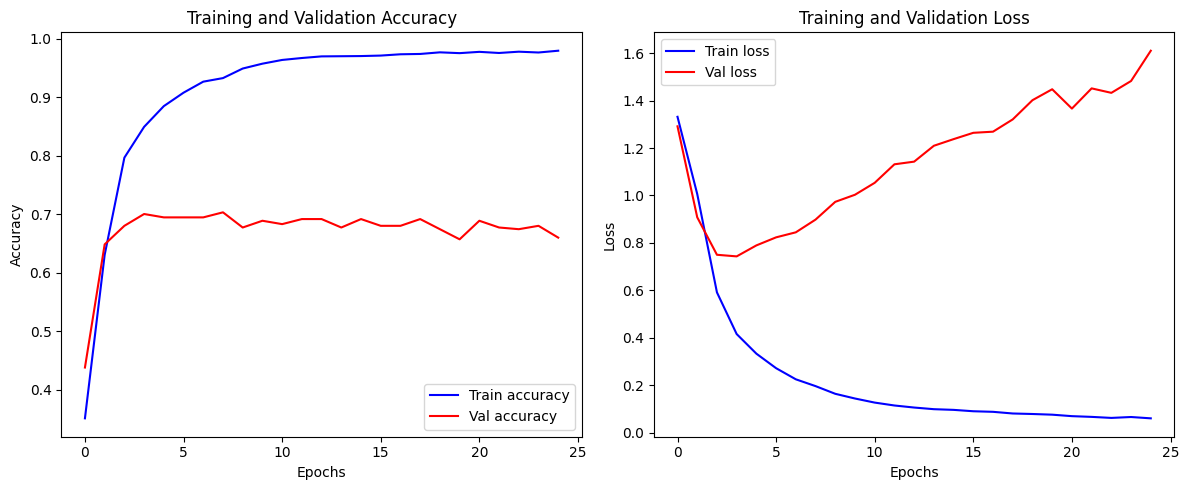

In [ ]:
# Answer here
import pandas as pd
import matplotlib.pyplot as plt


training_log = pd.read_csv("logs/training_log.csv")


print(training_log.columns)

# ---- Plot 1: Accuracy ----
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(training_log['epoch'], training_log['accuracy'], 'b', label='Train accuracy')
plt.plot(training_log['epoch'], training_log['val_accuracy'], 'r', label='Val accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# ---- Plot 2: Loss ----
plt.subplot(1, 2, 2)
plt.plot(training_log['epoch'], training_log['loss'], 'b', label='Train loss')
plt.plot(training_log['epoch'], training_log['val_loss'], 'r', label='Val loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

---

隨著訓練epoch的增加，訓練準確率持續提升，而驗證準確率成長較慢，甚至在某個階段後開始下降。
同時，訓練損失不斷降低，但驗證損失卻開始上升。
這表示模型出現過度擬合的情況，也就是模型學習了訓練資料中特有的模式，卻無法有效泛化到新的資料上。
相反地，若訓練與驗證的準確率皆偏低，且損失值始終維持在較高水準，則代表模型發生欠擬合，表示模型過於簡單或訓練不足。

### <a id='toc1_10_6_'></a>[Note](#toc0_)

If you don't have a GPU (level is higher than GTX 1060) or you are not good at setting lots of things about computer, we recommend you to use the [kaggle kernel](https://www.kaggle.com/kernels) to do deep learning model training. They have already installed all the librarys and provided free GPU for you to use.

Note however that you will only be able to run a kernel for 6 hours. After 6 hours of inactivity, your Kaggle kernel will shut down (meaning if your model takes more than 6 hours to train, you can't train it at once).


### <a id='toc1_10_7_'></a>[More Information for your reference](#toc0_)

* Keras document: https://keras.io/
* Keras GitHub example: https://github.com/keras-team/keras/tree/master/examples
* CS229: Machine Learning: http://cs229.stanford.edu/syllabus.html
* Deep Learning cheatsheet: https://stanford.edu/~shervine/teaching/cs-229/cheatsheet-deep-learning
* If you want to try TensorFlow or PyTorch: https://pytorch.org/tutorials/
https://www.tensorflow.org/tutorials/quickstart/beginner

---
## <a id='toc1_11_'></a>[**7. Word2Vector**](#toc0_)

We will introduce how to use `gensim` to train your word2vec model and how to load a pre-trained model.

https://radimrehurek.com/gensim/index.html

---
### <a id='toc1_11_1_'></a>[**7.1 Prepare training corpus**](#toc0_)

In [48]:
## check library
!pip install gensim

## ignore warnings
import warnings
warnings.filterwarnings('ignore')

# # if you want to see the training messages, you can use it
# import logging
# logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

## the input type
train_df['text_tokenized'] = train_df['text'].apply(lambda x: nltk.word_tokenize(x))
train_df[['id', 'text', 'text_tokenized']].head()

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   - -------------------------------------- 0.8/24.4 MB 5.6 MB/s eta 0:00:05
   ---- ----------------------------------- 2.9/24.4 MB 8.8 MB/s eta 0:00:03
   -------- ------------------------------- 5.2/24.4 MB 10.0 MB/s eta 0:00:02
   ------------ --------------------------- 7.6/24.4 MB 10.4 MB/s eta 0:00:02
   ---------------- ----------------------- 10.0/24.4 MB 10.7 MB/s eta 0:00:02
   ------------------- -------------------- 12.1/24.4 MB 10.5 MB/s eta 0:00:02
   ----------------------- ---------------- 14.2/24.4 MB 10.6 MB/s eta 0:00:01
   --------------------------- ------------ 16.8/24.4 MB 10.7 MB/s eta 0:00:01
   ------------------------------- -------- 19.1/24.4 MB 10.8 MB/s eta 0:00:01
   ----------------------------------- ---- 21.8/24.4 MB 10.9 MB/s eta 0:00:01
   ---------------------------------------  24.1/24.4 MB 11.1 MB/s eta 0:00:01
   ---------------------------------------- 24.4/24.4 MB 11.0 MB/s 

,id,text,text_tokenized
3172,40345,Im kind of confused. The one thing i do right...,"[Im, kind, of, confused, ., The, one, thing, i..."
3278,40451,"@Ren102e906 Just do what you can, don't get di...","[@, Ren102e906, Just, do, what, you, can, ,, d..."
2991,40164,@DeltaAssist Tried 2 get earlier flt 2day @BW...,"[@, DeltaAssist, Tried, 2, get, earlier, flt, ..."
3255,40428,"@ynnsanity Maybe that's why, we're asked to st...","[@, ynnsanity, Maybe, that, 's, why, ,, we, 'r..."
3553,40726,"There is no dark side in the moon. In fact, it...","[There, is, no, dark, side, in, the, moon, ., ..."


In [49]:
## create the training corpus
training_corpus = train_df['text_tokenized'].values
training_corpus[:3]

array([list(['Im', 'kind', 'of', 'confused', '.', 'The', 'one', 'thing', 'i', 'do', 'right', 'now', 'has', 'a', 'great', 'future', ',', 'but', 'on', 'the', 'other', 'hand', 'so', 'does', 'the', 'new', 'thing', '.', '#', 'needhelp']),
       list(['@', 'Ren102e906', 'Just', 'do', 'what', 'you', 'can', ',', 'do', "n't", 'get', 'discouraged', ',', 'maybe', 'some', 'prayers', 'for', 'divine', 'intervention', 'to', 'help', 'you', 'would', 'help', ':', ')']),
       list(['@', 'DeltaAssist', 'Tried', '2', 'get', 'earlier', 'flt', '2day', '@', 'BWI', 'Turnd', 'away', 'bcuz', 'it', 'was', '2', 'late', 'Then', 'agent', 'let', 'other', 'pas', 'on', '#', 'silvereliteleftbehind', '#', 'unhappy'])],
      dtype=object)

---
### <a id='toc1_11_2_'></a>[**7.2 Training our model**](#toc0_)

You can try to train your own model. More details: https://radimrehurek.com/gensim/models/word2vec.html

In [50]:
from gensim.models import Word2Vec

## setting
vector_dim = 100
window_size = 5
min_count = 1
training_epochs = 20

## model
word2vec_model = Word2Vec(sentences=training_corpus, 
                          vector_size=vector_dim, window=window_size, 
                          min_count=min_count, epochs=training_epochs)

![Imgur](https://i.imgur.com/Fca3MCs.png)

---
### <a id='toc1_11_3_'></a>[**7.3 Generating word vector (embeddings)**](#toc0_)

In [51]:
# get the corresponding vector of a word
word_vec = word2vec_model.wv['happy']
word_vec

array([ 0.3341102 ,  0.20882855,  0.35969684,  0.11331331, -0.69016284,
       -1.0717522 ,  0.8842924 ,  1.0210584 , -0.32979736, -0.5451183 ,
       -0.27737156, -0.32017332, -0.7094295 ,  0.28910652, -0.31094462,
       -0.71544755,  0.1199088 , -0.5694072 ,  0.21399117, -0.9561332 ,
        1.0084336 ,  0.7659585 ,  0.4675893 ,  0.35362357,  0.4151235 ,
        0.3493022 , -0.6857607 ,  0.41469327, -0.35620388,  0.3638465 ,
       -0.06234377, -0.13559908,  0.16293332, -0.7755265 , -0.17637049,
        0.21598333,  0.2873019 , -0.21304722, -0.45961195, -0.7553196 ,
       -0.56507933, -0.28351554, -0.43071818,  0.34838286,  0.52326924,
       -0.18331912, -0.7504081 ,  0.47755703,  0.27741   ,  0.5626892 ,
        0.12812956, -0.4666484 ,  0.01029554, -0.03707377, -0.7580899 ,
       -0.4064999 ,  0.23917446, -0.19070722,  0.04360669,  0.2975122 ,
        0.05296945, -0.4743881 ,  0.71675336,  0.49035463, -0.4682275 ,
        0.8304419 ,  0.1960237 ,  0.5812701 , -1.1049823 ,  0.58

In [52]:
# Get the most similar words
word = 'happy'
topn = 10
word2vec_model.wv.most_similar(word, topn=topn)

[('blessed', 0.9276823997497559),
 ('cats', 0.9144508838653564),
 ('Be', 0.9135326147079468),
 ('memories😊', 0.8971896767616272),
 ('birthday', 0.8930074572563171),
 ('smile', 0.8857895135879517),
 ('right', 0.885604739189148),
 ("'be", 0.8827837705612183),
 ('dad', 0.8807629942893982),
 ('bday', 0.8792546987533569)]

---
### <a id='toc1_11_4_'></a>[**7.4 Using a pre-trained w2v model**](#toc0_)

Instead of training your own model ,you can use a model that has already been trained. Here, we see 2 ways of doing that:


#### <a id='toc1_11_4_1_'></a>[(1) Download model by yourself](#toc0_)

Download from this link: [Kaggle | Google News Vectors](https://www.kaggle.com/datasets/didiersalazar/google-news-vectors)

Copy the data `GoogleNews-vectors-negative300.bin` into the following folder directory: `GoogleNews/`

source: [GoogleNews-vectors-negative300](https://code.google.com/archive/p/word2vec/)

more details: https://radimrehurek.com/gensim/models/keyedvectors.html

In [53]:
from gensim.models import KeyedVectors
# IMPORTANT: Please make sure that you have correctly downloaded the file and put it in the correct directory
## Note: this model is huge, this will take some time ...
model_path = "./GoogleNews/GoogleNews-vectors-negative300.bin"
w2v_google_model = KeyedVectors.load_word2vec_format(model_path, binary=True)
print('load ok')

w2v_google_model.most_similar('happy', topn=10)

load ok


[('glad', 0.7408890724182129),
 ('pleased', 0.6632170677185059),
 ('ecstatic', 0.6626912355422974),
 ('overjoyed', 0.6599286794662476),
 ('thrilled', 0.6514049172401428),
 ('satisfied', 0.6437949538230896),
 ('proud', 0.636042058467865),
 ('delighted', 0.627237856388092),
 ('disappointed', 0.6269949674606323),
 ('excited', 0.6247665286064148)]

#### <a id='toc1_11_4_2_'></a>[(2) Using gensim api](#toc0_)

Other pretrained models are available here: https://github.com/RaRe-Technologies/gensim-data

In [54]:
import gensim.downloader as api

## If you see `SSL: CERTIFICATE_VERIFY_FAILED` error, use this:
import ssl
import urllib.request
ssl._create_default_https_context = ssl._create_unverified_context

glove_twitter_25_model = api.load("glove-twitter-25")
print('load ok')

glove_twitter_25_model.most_similar('happy', topn=10)

load ok


[('birthday', 0.9577818512916565),
 ('thank', 0.937666654586792),
 ('welcome', 0.93361496925354),
 ('love', 0.9176183342933655),
 ('miss', 0.9164500832557678),
 ('hello', 0.9158351421356201),
 ('thanks', 0.915008544921875),
 ('merry', 0.9053249359130859),
 ('bless', 0.902732253074646),
 ('wish', 0.9013164043426514)]

---
### <a id='toc1_11_5_'></a>[**7.5 king + woman - man = ?**](#toc0_)

Let's run one of the most famous examples for Word2Vec and compute the similarity between these 3 words:

In [55]:
w2v_google_model.most_similar(positive=['king', 'woman'], negative=['man'])

[('queen', 0.7118193507194519),
 ('monarch', 0.6189674139022827),
 ('princess', 0.5902431011199951),
 ('crown_prince', 0.5499460697174072),
 ('prince', 0.5377321839332581),
 ('kings', 0.5236844420433044),
 ('Queen_Consort', 0.5235945582389832),
 ('queens', 0.518113374710083),
 ('sultan', 0.5098593235015869),
 ('monarchy', 0.5087411403656006)]

---
##### <a id='toc1_11_5_1_1_'></a>[**>>> Exercise 7 (Take home):**](#toc0_)

Now, we have the word vectors, but our input data is a sequence of words (or say sentence). 
How can we utilize these "word" vectors to represent the sentence data and train our model?


In [ ]:
# 預訓練的 Google Word2Vec 模型（GoogleNews-vectors-negative300.bin）
# 為每一個詞提供一個 300 維的向量表示。
# 然而，我們的資料集是由「句子」（包含多個詞）所組成，
# 因此需要將每個句子轉換成一個固定長度的向量。

# ----
# 以「詞向量平均」方式表示句子
# ---
import numpy as np

def sentence_to_vec(sentence, model):
    """
    將一句話轉換成單一向量，
    做法是對句子中所有詞的詞向量取平均。
    若某個詞不在模型中，則忽略該詞。
    """
    words = [w for w in sentence.split() if w in model.key_to_index]
    if len(words) == 0:
        return np.zeros(model.vector_size)
    return np.mean([model[w] for w in words], axis=0)

# 使用範例：
example_sentence = "I am very happy today"
sentence_vector = sentence_to_vec(example_sentence, w2v_google_model)
print("句子向量維度：", sentence_vector.shape)

# 查看與某個關鍵字最相似的前 10 個詞
print(w2v_google_model.most_similar('happy', topn=10))


# ---
# 使用句子向量訓練分類器
# ---
# 可以先將訓練與測試資料中的句子轉換成向量，
# 再使用傳統機器學習分類器（如 Logistic Regression、SVM 等）

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 範例：將訓練集與測試集文字轉換為平均詞向量
X_train_vec = np.vstack([sentence_to_vec(s, w2v_google_model) for s in train_df['text']])
X_test_vec = np.vstack([sentence_to_vec(s, w2v_google_model) for s in test_df['text']])

y_train = train_df['emotion']
y_test = test_df['emotion']

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vec, y_train)

y_pred = clf.predict(X_test_vec)
print("測試集準確率：", round(accuracy_score(y_test, y_pred), 3))


句子向量維度： (300,)
[('glad', 0.7408890724182129), ('pleased', 0.6632170677185059), ('ecstatic', 0.6626912355422974), ('overjoyed', 0.6599286794662476), ('thrilled', 0.6514049172401428), ('satisfied', 0.6437949538230896), ('proud', 0.636042058467865), ('delighted', 0.627237856388092), ('disappointed', 0.6269949674606323), ('excited', 0.6247665286064148)]
測試集準確率： 0.545


### 結果解讀：
透過對詞向量取平均，每個句子會被表示為一個 300 維的向量<br>
此方法計算效率高，但會喪失詞序資訊<br>
對於情緒或情感分類等簡單任務，通常仍能取得不錯的效果<br>
較進階的模型（如 LSTM 或 Transformer）能捕捉更豐富的語意關係，<br>
但需要更多資料與運算資源<br>

---
## <a id='toc1_12_'></a>[**8. Clustering: k-means**](#toc0_)

Here we introduce how to use `sklearn` to do the basic **unsupervised learning** approach, k-means.    

more details: http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html


#### <a id='toc1_12_1_1_'></a>[Basic concept](#toc0_)

![pic5.png](./pics/pic5.png)

(img source: https://towardsdatascience.com/k-means-clustering-identifying-f-r-i-e-n-d-s-in-the-world-of-strangers-695537505d)

In [76]:
# clustering target
target_list = ['happy', 'fear', 'angry', 'car', 'teacher', 'computer']
print('target words: ', target_list)

# convert to word vector
X = [word2vec_model.wv[word] for word in target_list]

target words:  ['happy', 'fear', 'angry', 'car', 'teacher', 'computer']


In [77]:
from sklearn.cluster import KMeans

# we have to decide how many cluster (k) we want
k = 2

# k-means model
kmeans_model = KMeans(n_clusters=k)
kmeans_model.fit(X)

# cluster result
cluster_result = kmeans_model.labels_

# show
for i in range(len(target_list)):
    print('word: {} \t cluster: {}'.format(target_list[i], cluster_result[i]))

word: happy 	 cluster: 1
word: fear 	 cluster: 1
word: angry 	 cluster: 1
word: car 	 cluster: 0
word: teacher 	 cluster: 0
word: computer 	 cluster: 0


![pic6.png](./pics/pic6.png)

In [78]:
#check cluster membership
word = 'student'
word_vec = word2vec_model.wv[word]
kmeans_model.predict([word_vec])

array([0], dtype=int32)

In [79]:
#check cluster membership
word = 'sad'
word_vec = word2vec_model.wv[word]
kmeans_model.predict([word_vec])

array([1], dtype=int32)

---
## <a id='toc1_13_'></a>[**9. High-dimension Visualization: t-SNE and UMAP**](#toc0_)

No matter if you use the Bag-of-words, TF-IDF, or Word2Vec, it's very hard to see the embedding result, because the dimension is larger than 3.  

In Lab 1, we already talked about PCA, t-SNE and UMAP. We can use PCA to reduce the dimension of our data, then visualize it. However, if you dig deeper into the result, you'd find it is insufficient.

Our aim will be to create a visualization similar to the one below with t-SNE:

![pic7.png](./pics/pic7.png)

source: https://www.fabian-keller.de/research/high-dimensional-data-visualization 

And also like this for UMAP:

![pic9.png](./pics/pic9.png)

source: https://umap-learn.readthedocs.io/en/latest/auto_examples/plot_mnist_example.html

t-SNE and UMAP reference:  
http://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html 
https://umap-learn.readthedocs.io/en/latest/

---
### <a id='toc1_13_1_'></a>[**9.1 Prepare visualizing target**](#toc0_)

Let's prepare data lists like:
- happy words
- angry words
- data words
- mining words

In [80]:
word_list = ['happy', 'angry', 'data', 'mining']

topn = 5
happy_words = ['happy'] + [word_ for word_, sim_ in w2v_google_model.most_similar('happy', topn=topn)]
angry_words = ['angry'] + [word_ for word_, sim_ in w2v_google_model.most_similar('angry', topn=topn)]        
data_words = ['data'] + [word_ for word_, sim_ in w2v_google_model.most_similar('data', topn=topn)]        
mining_words = ['mining'] + [word_ for word_, sim_ in w2v_google_model.most_similar('mining', topn=topn)]        

print('happy_words: ', happy_words)
print('angry_words: ', angry_words)
print('data_words: ', data_words)
print('mining_words: ', mining_words)

target_words = happy_words + angry_words + data_words + mining_words
print('\ntarget words: ')
print(target_words)

print('\ncolor list:')
cn = topn + 1
color = ['b'] * cn + ['g'] * cn + ['r'] * cn + ['y'] * cn
print(color)

happy_words:  ['happy', 'glad', 'pleased', 'ecstatic', 'overjoyed', 'thrilled']
angry_words:  ['angry', 'irate', 'enraged', 'indignant', 'incensed', 'annoyed']
data_words:  ['data', 'Data', 'datasets', 'dataset', 'databases', 'statistics']
mining_words:  ['mining', 'Mining', 'mines', 'coal_mining', 'mine', 'miner']

target words: 
['happy', 'glad', 'pleased', 'ecstatic', 'overjoyed', 'thrilled', 'angry', 'irate', 'enraged', 'indignant', 'incensed', 'annoyed', 'data', 'Data', 'datasets', 'dataset', 'databases', 'statistics', 'mining', 'Mining', 'mines', 'coal_mining', 'mine', 'miner']

color list:
['b', 'b', 'b', 'b', 'b', 'b', 'g', 'g', 'g', 'g', 'g', 'g', 'r', 'r', 'r', 'r', 'r', 'r', 'y', 'y', 'y', 'y', 'y', 'y']


---
### <a id='toc1_13_2_'></a>[**9.2 Plot using t-SNE and UMAP (2-dimension)**](#toc0_)

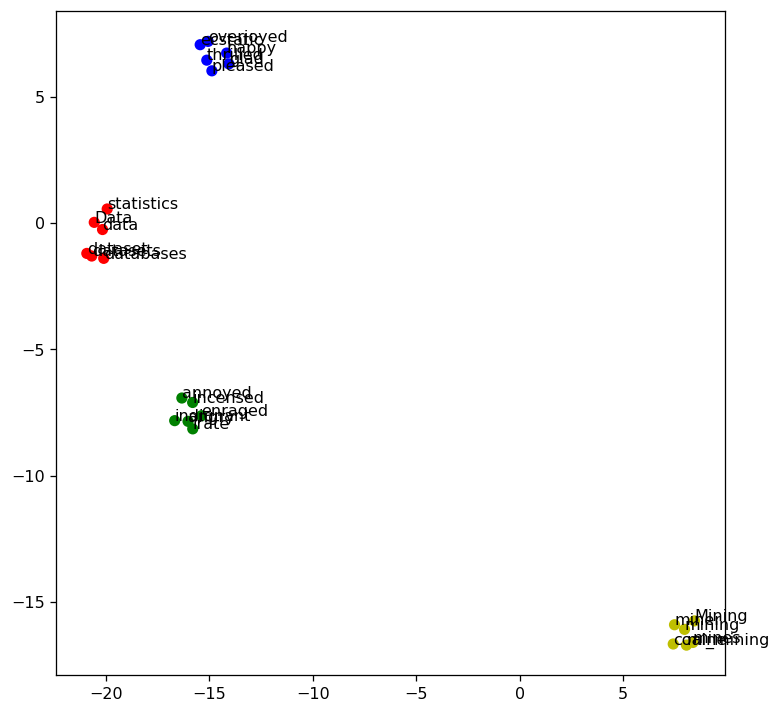

In [81]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

## w2v model
model = w2v_google_model

## prepare training word vectors
size = 200
target_size = len(target_words)
all_word = list(model.index_to_key)
word_train = target_words + all_word[:size]
X_train = model[word_train]

## t-SNE model
tsne = TSNE(n_components=2, metric='cosine', random_state=28)

## training
X_tsne = tsne.fit_transform(X_train)

## plot the result
plt.figure(figsize=(7.5, 7.5), dpi=115)
plt.scatter(X_tsne[:target_size, 0], X_tsne[:target_size, 1], c=color)
for label, x, y in zip(target_words, X_tsne[:target_size, 0], X_tsne[:target_size, 1]):
    plt.annotate(label, xy=(x,y), xytext=(0,0),  textcoords='offset points')
plt.show()

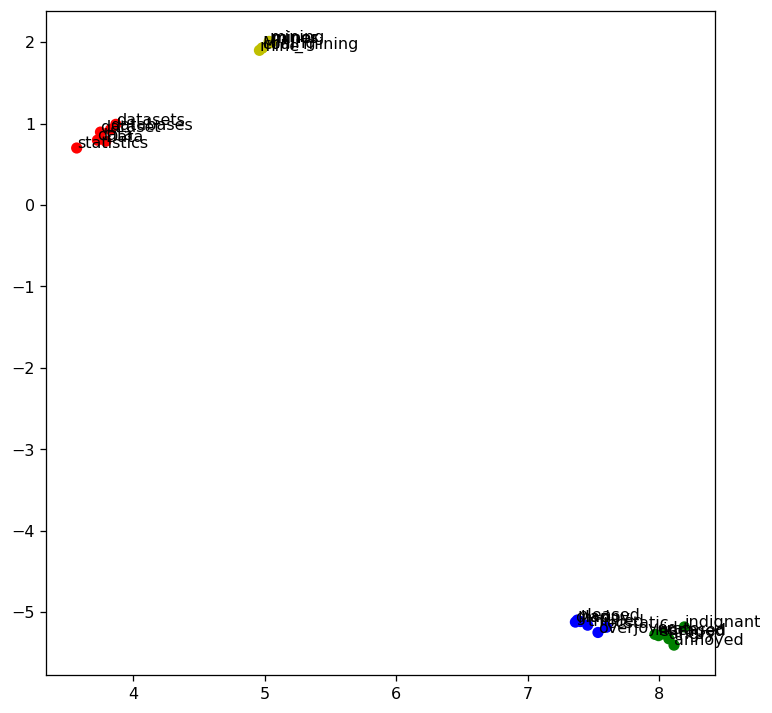

In [82]:
import matplotlib.pyplot as plt
import umap.umap_ as umap

## w2v model
model = w2v_google_model

## prepare training word vectors
size = 200
target_size = len(target_words)
all_word = list(model.index_to_key)
word_train = target_words + all_word[:size]
X_train = model[word_train]

## UMAP model
umap_model = umap.UMAP(n_components=2, metric='cosine', random_state=28)

## training
X_umap = umap_model.fit_transform(X_train)

## plot the result
plt.figure(figsize=(7.5, 7.5), dpi=115)
plt.scatter(X_umap[:target_size, 0], X_umap[:target_size, 1], c=color)
for label, x, y in zip(target_words, X_umap[:target_size, 0], X_umap[:target_size, 1]):
    plt.annotate(label, xy=(x,y), xytext=(0,0),  textcoords='offset points')
plt.show()


### 筆記：
視覺化上的差異（直觀）<br>
t-SNE<br>
把相似樣本拉得很近，形成漂亮的「團塊」。<br>
但不同團塊之間距離沒有意義。<br>
適合觀察「群內關係」。<br>
UMAP<br>
群之間的距離更有意義，保留整體結構。<br>
適合觀察「群與群之間的關聯」。<br>

---
##### <a id='toc1_13_2_1_1_'></a>[**>>> Exercise 8 (Take home):**](#toc0_)

Generate a t-SNE and UMAP visualization to show the 15 words most related to the words "angry", "happy", "sad", "fear" (60 words total). Compare the differences between both graphs.

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.7 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 8.8 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   -- ------------------------------------- 2.1/38.1 MB 11.7 MB/s eta 0:00:04
   ---- ----------------------------------- 4.5/38.1 MB 11.7 MB/s eta 0:00:03
   ------ --------------------------------- 6.6/38.1 MB 11.5 MB/s eta 0:00:03
   --------- ------------------------------ 9.2/38.1 MB 11.4 MB/s eta 0:00:03
   ------------ --------------------------- 11.5/38.1 MB 11.4 MB/s eta 0:00:03
   -------------- ------------------------- 13.9/38.1 MB 11.3 MB/s eta 0:00:03
   ----------------- ---------------------- 16.3/38.1 MB 11.4 MB/s eta 0:00:02
   ------------------- -------------------- 18.6/38.1 MB 11.3 MB/s eta 0:00:02
   --------------------- ------------------ 20.7/38.1 MB 11.4 MB/s eta 0:00:02
   --

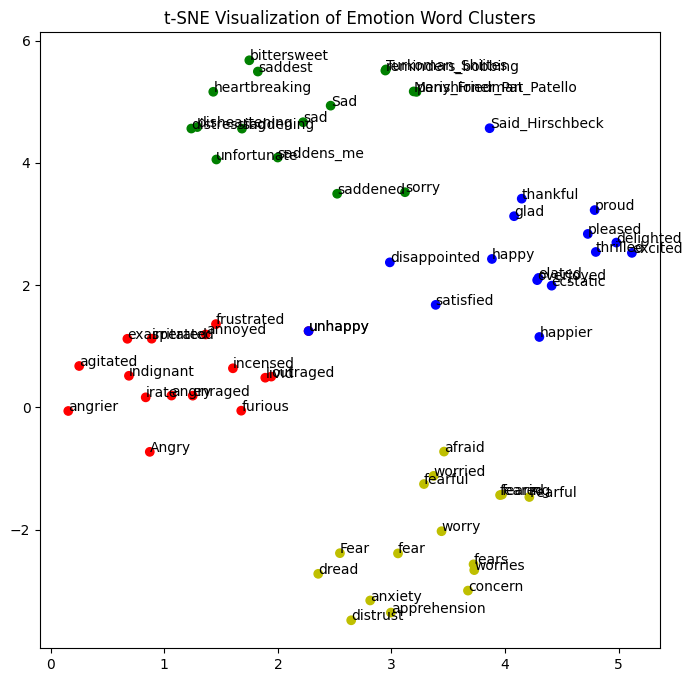

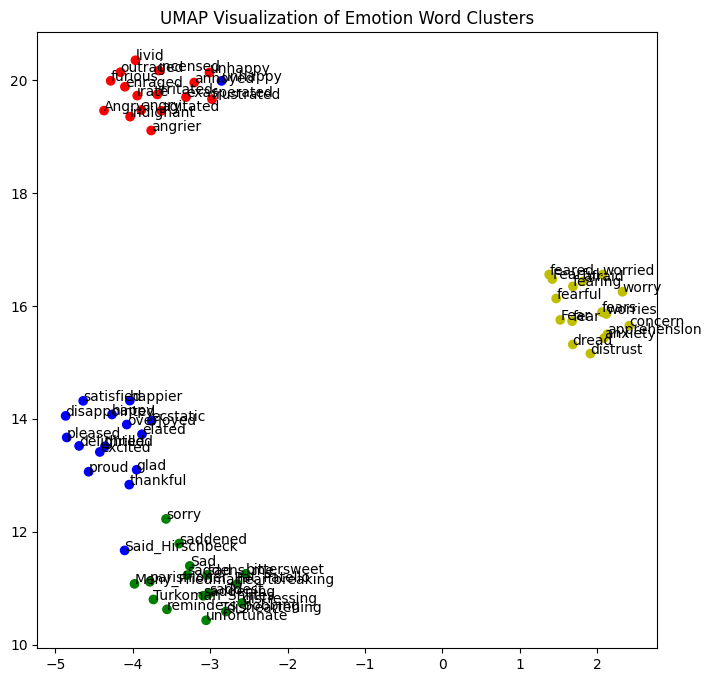

'\nt-SNE 與 UMAP（比較）\nt-SNE 更著重於保留局部關係。\n在語意上非常相近的詞（例如「angry」、「furious」、「mad」）\n會形成緊密的群集，但不同群集之間的距離並不具太多意義。\n\nUMAP 能較好地同時保留局部與全域結構。\n它通常能更清楚地呈現不同情緒群組之間的分離（例如快樂群與悲傷群），\n並顯示群組之間較為平滑的過渡關係。\n\n總結來說：\n- t-SNE：較適合用於探索細緻的局部群集結構。\n- UMAP：較適合用於視覺化整體關係以及群組之間的可分性。\n'

In [58]:
# Answer here
!pip install umap-learn

from gensim.models import KeyedVectors
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import umap.umap_ as umap

model = w2v_google_model

topn = 15
target_words = ['angry', 'happy', 'sad', 'fear']

word_groups = {}
for word in target_words:
    similar = [w for w, _ in model.most_similar(word, topn=topn)]
    word_groups[word] = [word] + similar  # 包含原詞


target_words_all = sum(word_groups.values(), [])
colors = ['r']*(topn+1) + ['b']*(topn+1) + ['g']*(topn+1) + ['y']*(topn+1)

# t-SNE 視覺化
X = model[target_words_all]
tsne = TSNE(n_components=2, metric='cosine', random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8,8))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=colors)
for label, x, y in zip(target_words_all, X_tsne[:,0], X_tsne[:,1]):
    plt.annotate(label, xy=(x,y), xytext=(0,0), textcoords='offset points')
plt.title("t-SNE Visualization of Emotion Word Clusters")
plt.show()

# UMAP 視覺化
umap_model = umap.UMAP(n_components=2, metric='cosine', random_state=42)
X_umap = umap_model.fit_transform(X)

plt.figure(figsize=(8,8))
plt.scatter(X_umap[:,0], X_umap[:,1], c=colors)
for label, x, y in zip(target_words_all, X_umap[:,0], X_umap[:,1]):
    plt.annotate(label, xy=(x,y), xytext=(0,0), textcoords='offset points')
plt.title("UMAP Visualization of Emotion Word Clusters")
plt.show()

# ----
#Interpretation
# ----
"""
t-SNE 與 UMAP（比較）
t-SNE 更著重於保留局部關係。
在語意上非常相近的詞（例如「angry」、「furious」、「mad」）
會形成緊密的群集，但不同群集之間的距離並不具太多意義。

UMAP 能較好地同時保留局部與全域結構。
它通常能更清楚地呈現不同情緒群組之間的分離（例如快樂群與悲傷群），
並顯示群組之間較為平滑的過渡關係。

總結來說：
- t-SNE：較適合用於探索細緻的局部群集結構。
- UMAP：較適合用於視覺化整體關係以及群組之間的可分性。
"""




---